# Gaussian (fBm) experiment — theta scaling analysis

This notebook loads a single `gaussian_experiment` run (MGD fit on fractional
Brownian motion / MRW increments — see `gaussian_experiment/run_SDE.py`) and
looks at the fitted Lagrange multipliers (`theta`), same idea as
`turbulence/turb_theta_scaling.ipynb` but for the much simpler Gaussian case.

Motivation, precisely stated: `Scattering_Fourth_Order_Mod2_Real_1d.forward()`
(`codes/potentials/potentials_1d.py`) computes the **raw** correlation
`E[ W_j(|Wx_s1|^2)(t) * W_j(|Wx_s2|^2)(t) ]` between the squared moduli of two
first-layer wavelet coefficients (fine scales `s1`, `s2`) — it does *not*
subtract a Gaussian baseline, so it is not a connected/cumulant statistic.

For jointly Gaussian `Wx` (guaranteed here: `x1` is fractional Gaussian
noise, a linear/stationary Gaussian process — see the data-generation cell
below), Isserlis'/Wick's theorem says this quantity is fully determined by
the *second*-order cross-correlation `Cov(Wx_s1, Wx_s2)`: it is exactly zero
when that cross-correlation is zero, and nonzero otherwise. Two things drive
that cross-correlation:
- the process's own power spectrum (flat/white for `H=0.5`, colored for
  `H != 0.5`);
- frequency-domain **overlap between the two wavelet filters themselves** —
  this codebase's filter bank (`codes/filters_bank.py`) is a redundant,
  continuous Morlet bank (not a critically-sampled orthogonal DWT), so
  immediately neighboring fine scales always overlap somewhat in frequency,
  for *any* input.

So the honest null-hypothesis prediction is **not** "flat zero everywhere":
it's "theta -> 0 for well-separated scale pairs `(s1, s2)`, with a small but
genuinely nonzero floor for near-diagonal pairs coming from filter-bank
leakage alone" (`indices_fourth_order_Q(..., offset=1)` already strips only
the exact self-pair `s1 == s2`, not a wider band around it — see
`codes/potentials/utils_potentials.py`). `H=0.5` (Brownian motion, i.e. white
noise increments) is the cleanest setting to check this, because it zeroes
out the spectrum's own contribution and isolates the filter-overlap floor;
moving to `H != 0.5` reintroduces real (but still purely second-order, not
non-Gaussian) cross-scale correlation from the fGn spectrum, which would
need to be compared against its analytic Gaussian value rather than literal
zero. This is the same statistic being computed on turbulence data, where
genuine non-Gaussian structure pushes it well past that Gaussian floor.

Steps in this first pass:
1. Load one experiment (data regeneration + saved SDE results + fitted potentials).
2. Plot the raw thetas, one panel per potential.
3. Apply the physical normalization (`codes/check_potentials.py`) and check
   the near-diagonal-vs-far-diagonal pattern described above.


In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt

# Notebook lives in gaussian_experiment/, mirroring run_SDE.py's own
# sys.path setup (see that file's module docstring for why this exact order
# matters: 'codes' and 'data' need to be importable both as packages and as
# bare top-level modules, since files under them cross-import each other
# both ways).
root = Path().resolve()
project_root = root.parent

for p in (root, project_root, project_root / 'codes', project_root / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from codes.sde_routines import *
from codes.utils import *
from codes.utils_experiment import *
from codes.check_moments import *
from codes.potentials_builder import *
from codes.filters_bank import *
from codes.check_potentials import *          # theta scaling / normalization toolkit
from codes.ortho_wavelet.ReadyToUseWavelets import *
from data.synthetic_data_generator import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('root:', root)


device: cuda
root: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/gaussian_experiment


## 1. Experiment parameters

Fill these in to match the run you want to inspect (same fields
`build_config_name` hashes into the config string — see
`codes/utils_experiment.py`). Leave `label`/`timestamp` empty to let the
resolver find the latest matching run on disk.


In [10]:
J = 7
Q = 1
M = 128
hurst = 0.5            # 0.5 = standard Brownian motion; fBm increments are Gaussian either way
intermittency = 0.0    # 0.0 -> pure fBm (Gaussian increments); >0 adds MRW multifractal modulation
sigma = 1.0
nt = 500
n1 = 1000
lam = 5e-6
regularization = 1e-2
n_subsample = 1
seed = 0

terms=[
    'Scattering_First_Order', 
    'Scattering_Second_Order',
    'Scattering_Fourth_Order_Mod2_Real_Q1',
    'Scattering_Fourth_Order_Mod2_Imag_Q1',
]

args = SimpleNamespace(
    J=J, Q=Q, hurst=hurst, intermittency=intermittency,
    sigma=sigma, nt=nt, n1=n1, lam=lam,
    regularization=regularization, n_subsample=n_subsample,
    terms=terms, seed=seed,
    interpolant='Cos', batch_size=None,
    label='fit_micro_test',        # set to the exact label if the run used --label
    timestamp='',    # left empty -> resolver finds the latest matching run
    force_rerun=False,
)

REAL_KEY = 'Scattering_Fourth_Order_Mod2_Real_Q1'
IMAG_KEY = 'Scattering_Fourth_Order_Mod2_Imag_Q1'
COMPLEX_NAME = 'Scattering_Fourth_Order_Mod2_Q1'


## 2. Regenerate the data

`x1` is never saved to disk — `run_SDE.py` regenerates it from the RNG seed
every time (see its `main()`). We need the *exact same* `x1` here, both
because it's what the fitted potentials were evaluated on, and because the
normalization below (`compute_norm_jab` / `compute_mk`) is data-dependent.


In [11]:
torch.manual_seed(args.seed)
np.random.seed(args.seed)

raw = load_synthetic_data(
    'mrw', args.n1, M + 1,
    lam=args.intermittency, H=args.hurst,
).to(device)
increments = raw.diff(dim=-1)
x1 = normalize(increments).to(device)

print('x1 shape:', tuple(x1.shape), x1.device)


Model MRW: generating data ...


100%|##########| 16/16 [00:00<00:00, 524.07it/s]


Finished.
x1 shape: (1000, 1, 128) cuda:0


## 3. Resolve and load the saved run


In [12]:
config_prefix = build_config_name(args, M, coarse_grained=False, include_timestamp=False)
print('config prefix:', config_prefix)

resolved_config = resolve_config_for_loading(root, config_prefix)
if resolved_config is None:
    raise FileNotFoundError(
        f"No saved run matches prefix '{config_prefix}' under {root / 'saved_results'}. "
        f"Check the parameters in the cell above against the run you actually launched."
    )
print('resolved config:', resolved_config)

loaded = try_load_experiment(root, resolved_config, device)
if loaded is None or not loaded.get('loaded', False):
    raise RuntimeError(f"Failed to load saved results for {resolved_config}")

theta_t = loaded['theta_t']
Theta_reg = loaded['Theta_reg']
t = loaded['t']
print('theta_t shape:', tuple(theta_t.shape))
if Theta_reg is not None:
    print('Theta_reg shape:', tuple(Theta_reg.shape))


config prefix: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q1_sigma1.0_nt500_n1_1000_lam5e-06_seed_0_termsf930d93e_fit_micro_test
resolved config: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q1_sigma1.0_nt500_n1_1000_lam5e-06_seed_0_termsf930d93e_fit_micro_test
theta_t shape: (495, 106)
Theta_reg shape: (494, 106)


## 4. Load the fitted potentials

Rebuild the nominal potentials (same call `run_experiment` used internally)
then overwrite each fitted one with its saved state from
`experiments/<config>/fitted_potentials/`.


In [13]:
filters, filters_Phi = return_Filters(M, args.J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, args.J, args.Q, device=device)

potentials = get_1d_potentials(
    terms, args.J, filters, args.Q,
    scalar_param=None, parallel=False,
    filters_Q=filters_Q, filters_Phi=filters_Phi,
)
for pot in potentials.values():
    if hasattr(pot, 'fit_micro'):
        pot.fit_micro(x1)   # x1 is already regenerated identically above (same seed)
# potentials_dir = root / 'experiments' / resolved_config / 'fitted_potentials'
# if not potentials_dir.exists():
#     raise FileNotFoundError(f"No fitted_potentials dir at {potentials_dir}")

# for name, p in potentials.items():
#     p.to(device)
#     if not hasattr(p, 'is_fitted'):
#         continue
#     state_path = potentials_dir / f'{name}.pt'
#     if not state_path.exists():
#         raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
#     own_filters = p.filters
#     loaded_p = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
#     loaded_p.to(device)
#     potentials[name] = loaded_p

theta_final = theta_t[-1].detach().cpu().numpy() if torch.is_tensor(theta_t) else np.asarray(theta_t)[-1]

total_dim = sum(p.num_coefficients for p in potentials.values())
print(f"sum(num_coefficients) = {total_dim}, theta_final dim = {len(theta_final)}")
assert total_dim == len(theta_final), (
    "Fitted potentials' pruned layout doesn't match theta_t's feature count -- "
    "double check `terms`/J/Q above against the actual run."
)


sum(num_coefficients) = 106, theta_final dim = 106


## 5. Raw thetas

`build_all_averaged_vectors` is written for averaging *across seeds*
(stacking several runs' final-time theta into one matrix); with a single
run it's just the identity — passing a `(1, n_features)` matrix "averages"
over one row. Reusing it here (instead of a bespoke plot) keeps this
notebook consistent with the turbulence scaling notebook's tooling, and
gets the Real/Imag scattering pair collapsed into one complex vector for
free.


Scattering_First_Order                   shape=(7,)  (real)
Scattering_Second_Order                  shape=(8,)  (real)
Scattering_Fourth_Order_Mod2_Q1          shape=(56,)  (complex)


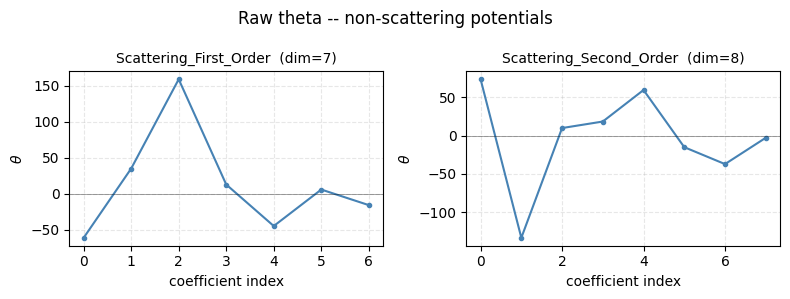

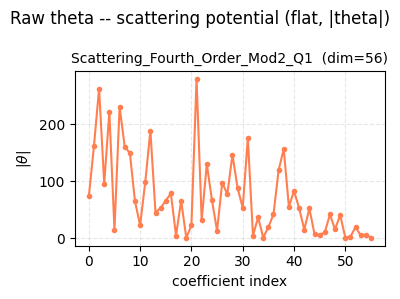

In [14]:
theta_vectors = build_all_averaged_vectors(
    theta_final[None, :], potentials, terms,
    real_imag_pairs=[(REAL_KEY, IMAG_KEY, COMPLEX_NAME)],
)

for name, vec in theta_vectors.items():
    kind = 'complex' if np.iscomplexobj(vec) else 'real'
    print(f"{name:40s} shape={vec.shape}  ({kind})")

non_scattering_names = [k for k in theta_vectors if k != COMPLEX_NAME]
plot_theta_by_potential(theta_vectors, potential_names=non_scattering_names,
                         title='Raw theta -- non-scattering potentials')

if COMPLEX_NAME in theta_vectors:
    plot_theta_by_potential(theta_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                             title='Raw theta -- scattering potential (flat, |theta|)')
else:
    print(f"No scattering potential ({COMPLEX_NAME}) in this run's terms -- skipping.")

## 6. Normalization

`build_theta_dataframe` / `build_complex_theta_dataframe` (in
`codes/check_potentials.py`) convert the raw fitted `theta` into the
*physical* micro-normalized quantity
`theta_physical = theta_fitted * (E[|Wx_s1|^2] * E[|Wx_s2|^2]) ** (norm_order/4)`
computed on `x1` itself (`compute_norm_jab`) for potentials with scattering
(j, s1, s2) index structure, or `theta_fitted * m_k` (`compute_mk`) as a
fallback for potentials without one (`L_2_lowpass`, `Scalar_*`).

This is the quantity to look at: raw `theta` alone is not directly
comparable across coefficients living at different wavelet scales, but the
normalized value is. For the scattering potential specifically, the
dataframe carries `k_prime` (`s1`) and `k` (`s2`) — the fine-scale indices
whose separation `|s1 - s2|` is exactly what the argument above says should
control the magnitude: small near the diagonal (filter overlap), decaying
towards 0 once the two scales' filters stop overlapping.


In [18]:
m_k = compute_mk(potentials, x1)

dfs = {}
for key in terms:
    if key in (REAL_KEY, IMAG_KEY):
        continue
    dfs[key] = build_theta_dataframe(
        theta_final, potentials, key, x1=x1, filters=filters, m_k=m_k,
    )
    

if REAL_KEY in terms and IMAG_KEY in terms:
    dfs[COMPLEX_NAME] = build_complex_theta_dataframe(
        theta_final, potentials, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
        # norm_order left as None -> auto-inferred to 4 since 'Mod2' is in REAL_KEY
    )
    
for key, df in dfs.items():
    value_col = 'theta_complex' if 'theta_complex' in df.columns else 'theta_t1'
    norm_col = value_col + '_normalized'
    # theta was fit against ALREADY-normalized phi (fit_micro ran pre-SDE) --
    # theta_raw IS the physical value now. Overwrite compute_norm_jab/m_k's
    # multiplication (which assumes an unnormalized fit) so it becomes a
    # no-op instead of double-normalizing.
    df[norm_col] = df[value_col]
    
for key, df in dfs.items():
    value_col = 'theta_complex' if 'theta_complex' in df.columns else 'theta_t1'
    norm_col = value_col + '_normalized'
    raw_abs = df[value_col].abs()
    norm_abs = df[norm_col].abs()
    print(f"{key:40s}  raw |theta|: mean={raw_abs.mean():.3e} max={raw_abs.max():.3e}"
          f"   normalized |theta|: mean={norm_abs.mean():.3e} max={norm_abs.max():.3e}")

# The scattering potential's null-hypothesis prediction is NOT flat zero --
# it's ~0 for well-separated (s1, s2) scale pairs, with a small but genuine
# floor near the diagonal from filter-bank overlap alone (see the intro
# markdown). Split by |s1 - s2| = |k_prime - k| to check that shape directly,
# rather than averaging it away against a single flat number.
if COMPLEX_NAME in dfs:
    df_scat = dfs[COMPLEX_NAME].copy()
    df_scat['scale_gap'] = (df_scat['k_prime'] - df_scat['k']).abs()
    gap_summary = (
        df_scat.assign(abs_norm=df_scat['theta_complex_normalized'].abs())
        .groupby('scale_gap')['abs_norm']
        .agg(['mean', 'max', 'count'])
    )
    print(f"\n{COMPLEX_NAME}: |theta_normalized| by fine-scale separation |s1-s2|")
    print(gap_summary)


Scattering_First_Order                    raw |theta|: mean=4.779e+01 max=1.591e+02   normalized |theta|: mean=4.779e+01 max=1.591e+02
Scattering_Second_Order                   raw |theta|: mean=4.357e+01 max=1.330e+02   normalized |theta|: mean=4.357e+01 max=1.330e+02
Scattering_Fourth_Order_Mod2_Q1           raw |theta|: mean=7.223e+01 max=2.788e+02   normalized |theta|: mean=7.223e+01 max=2.788e+02

Scattering_Fourth_Order_Mod2_Q1: |theta_normalized| by fine-scale separation |s1-s2|
                mean         max  count
scale_gap                              
1          86.683220  278.840637     21
2          82.593628  230.830154     15
3          68.278687  188.921402     10
4          32.322956   78.720695      6
5          28.792259   65.814201      3
6          22.661856   22.661856      1


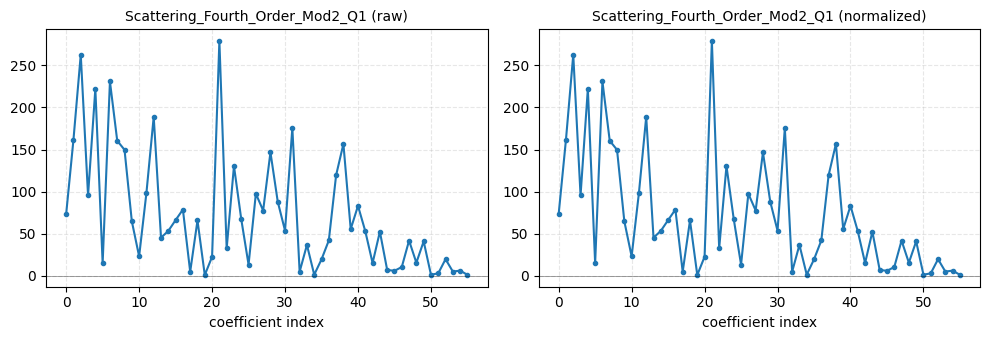

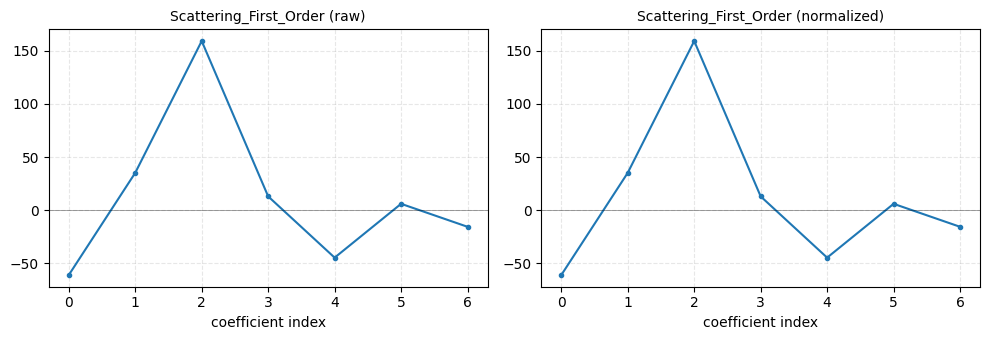

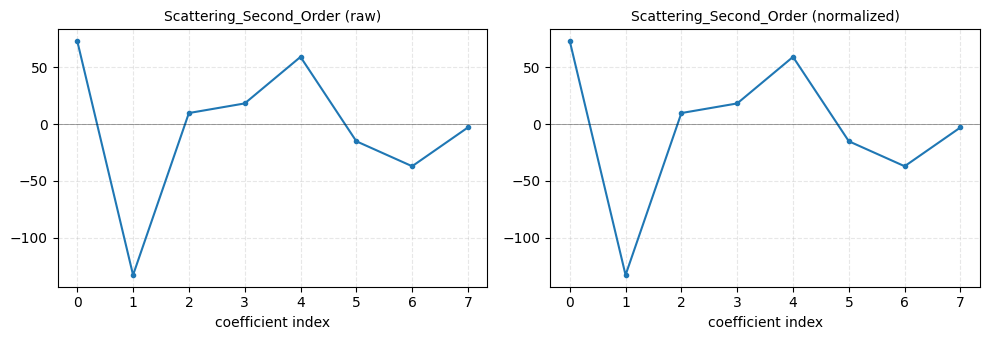

In [16]:
%matplotlib inline

def plot_raw_vs_normalized(df, key):
    value_col = 'theta_complex' if 'theta_complex' in df.columns else 'theta_t1'
    norm_col = value_col + '_normalized'
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, col, title in zip(axes, (value_col, norm_col), ('raw', 'normalized')):
        y = df[col].to_numpy()
        y = np.abs(y) if np.iscomplexobj(y) else y
        ax.plot(df['coeff_idx'], y, 'o-', ms=3)
        ax.axhline(0, color='black', lw=0.5, alpha=0.5)
        ax.set_title(f'{key} ({title})', fontsize=10)
        ax.set_xlabel('coefficient index')
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

if COMPLEX_NAME in dfs:
    plot_raw_vs_normalized(dfs[COMPLEX_NAME], COMPLEX_NAME)

for key, df in dfs.items():
    if key == COMPLEX_NAME:
        continue
    plot_raw_vs_normalized(df, key)


                                 raw_mean_abs  norm_mean_abs
potential                                                   
Scattering_First_Order              47.788670      47.788670
Scattering_Second_Order             43.574711      43.574711
Scattering_Fourth_Order_Mod2_Q1     72.232414      72.232414


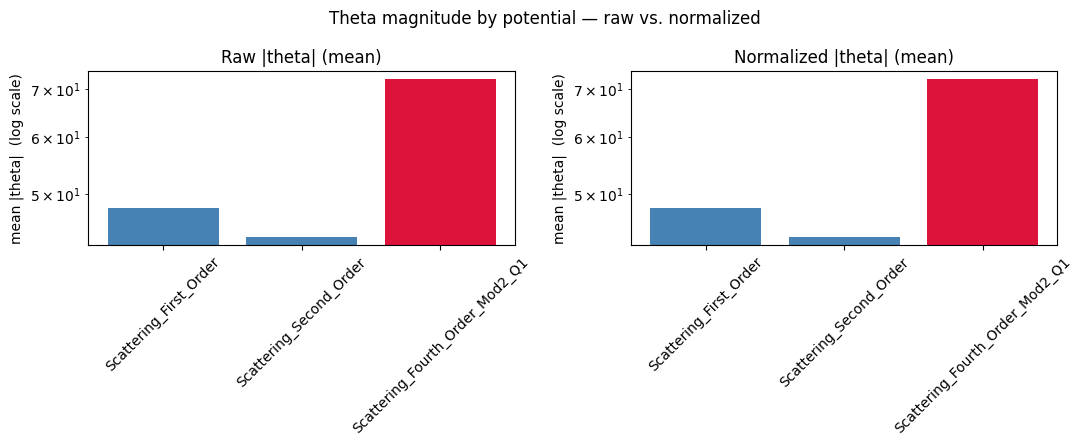


Scattering_Fourth_Order_Mod2_Q1 mean|theta|  /  mean over other potentials' mean|theta|:
  raw:        1.58x
  normalized: 1.58x


In [17]:
summary_rows = []
for key, df in dfs.items():
    value_col = 'theta_complex' if 'theta_complex' in df.columns else 'theta_t1'
    norm_col = value_col + '_normalized'
    summary_rows.append({
        'potential': key,
        'raw_mean_abs': df[value_col].abs().mean(),
        'norm_mean_abs': df[norm_col].abs().mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index('potential')
print(summary_df.round(6))

# Scattering-4th-order carries no real information on Gaussian data, so its
# theta should collapse toward the other potentials' floor once the
# normalization is doing its job -- highlight it distinctly to see whether
# it does.
colors = ['crimson' if k == COMPLEX_NAME else 'steelblue' for k in summary_df.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title in zip(axes, ('raw_mean_abs', 'norm_mean_abs'),
                          ('Raw |theta| (mean)', 'Normalized |theta| (mean)')):
    ax.bar(summary_df.index, summary_df[col], color=colors)
    ax.set_yscale('log')
    ax.set_ylabel('mean |theta|  (log scale)')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
fig.suptitle('Theta magnitude by potential — raw vs. normalized')
fig.tight_layout()
plt.show()

if COMPLEX_NAME in summary_df.index:
    others = summary_df.drop(index=COMPLEX_NAME)
    ratio_raw = summary_df.loc[COMPLEX_NAME, 'raw_mean_abs'] / others['raw_mean_abs'].mean()
    ratio_norm = summary_df.loc[COMPLEX_NAME, 'norm_mean_abs'] / others['norm_mean_abs'].mean()
    print(f"\n{COMPLEX_NAME} mean|theta|  /  mean over other potentials' mean|theta|:")
    print(f"  raw:        {ratio_raw:.2f}x")
    print(f"  normalized: {ratio_norm:.2f}x")

## Next steps

Once this loads a real run, natural refinements:
- Break the scattering theta down `|theta|` vs `k` (per `j`) and vs `j`
  (per `k`), the way `turb_theta_scaling.ipynb`'s
  `plot_modulus_vs_k_grid` / `plot_modulus_vs_j_grid` do, to see the
  near-diagonal-vs-far-diagonal decay shape directly instead of via the
  `scale_gap` groupby above.
- Compute the *analytic* Gaussian baseline for `H != 0.5` runs (from the fGn
  power spectrum and the filter bank's transfer functions) and compare
  against that instead of literal zero -- needed as soon as `--hurst` moves
  away from 0.5, per the intro markdown.
- Compare across `--intermittency` values (0 = Gaussian vs. >0 =
  multifractal) to see the far-diagonal thetas grow away from the Gaussian
  floor as the data becomes genuinely non-Gaussian.
- Compare across seeds (mean +/- std the way the turbulence notebook does
  for `Theta_reg`/`theta_MGD`) to get an error bar on the floor rather than
  a single point estimate.
